# Attention SCSE U-Net — бинарная сегментация тепловых дефектов

Пайплайн:

```
TermoDataset (T, H, W)  →  extract_channels  →  (5, H, W)
  →  1×1 Adapter (5→3)  →  smp.Unet + SCSE  →  mask
```

Гиперпараметры — в первой ячейке. Чекпоинты в том же pickle-формате, что и
`models/Thermal-Contrast/checkpoint.py` (`Checkpoint` + `save_checkpoint` / `load_checkpoint`).


In [6]:
# === гиперпараметры (меняй здесь для экспериментов) ===

# Модель
ENCODER_NAME = "resnet34"
PRETRAINED = True
ATTENTION_TYPE = "scse"   # scse | None

# Порядок каналов на входе адаптера: информативные (Chulkov) первыми
ADAPTER_CHANNEL_ORDER = ("tsr_d1", "tsr_d2", "pca1", "std", "maxmin")

# Оптимизатор (Differential Learning Rate)
LR_ENCODER = 1e-4
LR_HEAD = 1e-3
WEIGHT_DECAY = 1e-4

# Обучение
EPOCHS = 50
BATCH_SIZE = 4
NUM_WORKERS = 0
VAL_RATIO = 0.2
SEED = 42
DEVICE = "mps"           # auto | cuda | mps | cpu
THRESHOLD = 0.5
RESUME_FROM = None        # None | путь к .pkl для дообучения

# Каналы / данные
NUM_FRAMES = 64           # ChannelParams.num_frames
INCLUDE = None            # None → все поддатасеты; или ["dataset_kaggle"]
DATA_ROOT = "datasets/datasets_list"
CHECKPOINT_DIR = "experiments/checkpoints/att_unet/"


## Импорты и пути

`TermoDataset` — из `datasets/`. Каналы и чекпоинты — из `models/Thermal-Contrast/`.
Метрики и device — из `models/common/`.


In [7]:
import importlib
import sys
from pathlib import Path

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "models" / "Thermal-Contrast").is_dir() and (p / "datasets").is_dir()
)
TC_DIR = ROOT / "models" / "Thermal-Contrast"
for p in (ROOT, ROOT / "models", TC_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import paths  # noqa: F401 — sys.path для datasets / common

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from IPython.display import clear_output, display
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

import channels as channels_mod
importlib.reload(channels_mod)
from channels import (
    CHANNEL_NAMES,
    CHANNEL_TITLES,
    NUM_CHANNELS,
    ChannelParams,
    DEFAULT_PARAMS,
    extract_channels,
)
from checkpoint import (
    Checkpoint,
    load_checkpoint,
    load_model,
    move_optimizer_state_to_device,
    save_checkpoint,
)
from common.device import get_device
from common.metrics import dice_score, iou_score
from datasets import TermoDataset

PARAMS = ChannelParams(num_frames=NUM_FRAMES)
device = get_device(DEVICE)
ckpt_dir = (ROOT / CHECKPOINT_DIR).resolve()
ckpt_dir.mkdir(parents=True, exist_ok=True)
BEST_PATH = ckpt_dir / "best.pkl"
LAST_PATH = ckpt_dir / "last.pkl"

# индексы перестановки: extract_channels → порядок адаптера
assert set(ADAPTER_CHANNEL_ORDER) == set(CHANNEL_NAMES)
CHANNEL_PERM = [CHANNEL_NAMES.index(n) for n in ADAPTER_CHANNEL_ORDER]

print(f"ROOT={ROOT}")
print(f"device={device}  encoder={ENCODER_NAME}  attention={ATTENTION_TYPE}")
print(f"channels extract={list(CHANNEL_NAMES)}")
print(f"channels adapter={list(ADAPTER_CHANNEL_ORDER)}  perm={CHANNEL_PERM}")
print(f"checkpoints → {ckpt_dir}")


ROOT=/Users/user/Education/CVYandexCamp/thermal-control-ya-project
device=mps  encoder=resnet34  attention=scse
channels extract=['maxmin', 'std', 'pca1', 'tsr_d1', 'tsr_d2']
channels adapter=['tsr_d1', 'tsr_d2', 'pca1', 'std', 'maxmin']  perm=[3, 4, 2, 1, 0]
checkpoints → /Users/user/Education/CVYandexCamp/thermal-control-ya-project/experiments/checkpoints/att_unet


## Данные

`TermoDataset` отдаёт сырое видео `(T, H, W)` и маску `(H, W)`.
`collate_fn` вызывает `extract_channels` и ставит каналы в порядок адаптера
`(tsr_d1, tsr_d2, pca1, std, maxmin)`. Split 80/20 по индексам видео (без утечки кадров).


In [8]:
def collate_channels(batch):
    """Список (video, mask) → (B, 5, H, W), (B, 1, H, W)."""
    channels_list, masks = [], []
    for video, mask in batch:
        ch = extract_channels(video, PARAMS)           # (5, H, W) в порядке CHANNEL_NAMES
        ch = ch[CHANNEL_PERM]                            # → ADAPTER_CHANNEL_ORDER
        channels_list.append(ch)
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
        masks.append((mask > 0).float())
    return torch.stack(channels_list), torch.stack(masks)


data_root = ROOT / DATA_ROOT
full_ds = TermoDataset(root_dir=str(data_root), include=INCLUDE)
n = len(full_ds)
n_val = max(1, int(round(n * VAL_RATIO)))
n_train = n - n_val

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n, generator=g).tolist()
train_idx, val_idx = perm[:n_train], perm[n_train:]

train_ds = Subset(full_ds, train_idx)
val_ds = Subset(full_ds, val_idx)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=collate_channels,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_channels,
)

x0, y0 = next(iter(train_loader))
print(f"videos: {n}  train={len(train_ds)}  val={len(val_ds)}")
print(f"batch: x={tuple(x0.shape)} y={tuple(y0.shape)}  x∈[{x0.min():.2f}, {x0.max():.2f}]")
for i, name in enumerate(ADAPTER_CHANNEL_ORDER):
    print(f"  adapter ch{i}: {name} ({CHANNEL_TITLES[name]})")


videos: 56  train=45  val=11
batch: x=(4, 5, 256, 256) y=(4, 1, 256, 256)  x∈[0.00, 1.00]
  adapter ch0: tsr_d1 (TSR d/dln(t))
  adapter ch1: tsr_d2 (TSR d²/dln(t)²)
  adapter ch2: pca1 (PCA₁(t))
  adapter ch3: std (σ(t))
  adapter ch4: maxmin (max - min)


## Архитектура

### Проблема доменного сдвига

ResNet34 в ImageNet видит **3 RGB-канала**. У нас **5 физических карт** теплопередачи
(`tsr_d1`, `tsr_d2`, `pca1`, `std`, `maxmin`). Нельзя просто сменить `in_channels=5` и
ждать, что pretrained-веса первого свёрточного слоя останутся осмысленными.

### Learnable 1×1 Adapter

`Conv2d(5 → 3, kernel=1, bias=False)` перед энкодером. Инициализация:

| вход (порядок адаптера) | вклад в RGB |
|---|---|
| 0–2: `tsr_d1`, `tsr_d2`, `pca1` | вес **1.0** на R / G / B соответственно (прямое копирование) |
| 3–4: `std`, `maxmin` | вес **1/3** на все три выхода (усреднение) |

Так все пять каналов сразу имеют ненулевой градиент, а три самых информативных
(Chulkov Seq 5–7) стартуют как «RGB».

### U-Net + SCSE

`smp.Unet(..., in_channels=3, decoder_attention_type="scse")` — attention в декодере.
Выход с `sigmoid` → вероятности дефекта.


In [9]:
class ChannelAdapter(nn.Module):
    """5 физических каналов → 3 псевдо-RGB для pretrained encoder."""

    def __init__(self, in_ch: int = 5, out_ch: int = 3):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        self._init_weights()

    @torch.no_grad()
    def _init_weights(self) -> None:
        w = torch.zeros_like(self.proj.weight)  # (3, 5, 1, 1)
        # каналы 0,1,2 → R,G,B с весом 1
        for i in range(3):
            w[i, i, 0, 0] = 1.0
        # каналы 3,4 → усреднение по всем RGB
        for j in (3, 4):
            w[:, j, 0, 0] = 1.0 / 3.0
        self.proj.weight.copy_(w)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(x)


class AttSCSEUNet(nn.Module):
    def __init__(
        self,
        encoder_name: str = ENCODER_NAME,
        pretrained: bool = PRETRAINED,
        attention_type: str | None = ATTENTION_TYPE,
    ):
        super().__init__()
        self.adapter = ChannelAdapter(NUM_CHANNELS, 3)
        self.unet = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights="imagenet" if pretrained else None,
            in_channels=3,
            classes=1,
            activation="sigmoid",
            decoder_attention_type=attention_type,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.unet(self.adapter(x))


model = AttSCSEUNet().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"model params: {n_params:,}")
with torch.no_grad():
    y = model(x0.to(device))
print(f"forward: {tuple(x0.shape)} → {tuple(y.shape)}")
print("adapter weight (3×5):\n", model.adapter.proj.weight.detach().cpu().squeeze().numpy().round(3))


'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/smp-hub/resnet34.imagenet/resolve/7a57b34f723329ff020b3f8bc41771163c519d0c/model.safetensors
Retrying in 1s [Retry 1/5].


model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

model params: 24,550,375
forward: (4, 5, 256, 256) → (4, 1, 256, 256)
adapter weight (3×5):
 [[1.    0.    0.    0.333 0.333]
 [0.    1.    0.    0.333 0.333]
 [0.    0.    1.    0.333 0.333]]


## Оптимизатор, loss, чекпоинты

**Differential LR:** энкодер — `LR_ENCODER` (fine-tune), адаптер + декодер — `LR_HEAD`.

**Loss:** `DiceLoss(mode='binary', from_logits=False) + BCELoss` (модель уже с sigmoid).

Чекпоинты — через `save_checkpoint` / `load_checkpoint` из Thermal-Contrast
(`epoch`, `best_iou`, `model_state`, `optimizer_state`, `scheduler_state`, `history`, `params`).


In [10]:
def param_groups(model: AttSCSEUNet):
    encoder_ids = {id(p) for p in model.unet.encoder.parameters()}
    encoder_params, head_params = [], []
    for p in model.parameters():
        if not p.requires_grad:
            continue
        (encoder_params if id(p) in encoder_ids else head_params).append(p)
    return [
        {"params": encoder_params, "lr": LR_ENCODER},
        {"params": head_params, "lr": LR_HEAD},
    ]


dice_loss = DiceLoss(mode="binary", from_logits=False)
bce_loss = nn.BCELoss()


def criterion(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return dice_loss(pred, target) + bce_loss(pred, target)


optimizer = torch.optim.AdamW(param_groups(model), weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history: list[dict] = []
start_epoch = 1
best_iou = -1.0
best_epoch = -1

if RESUME_FROM is not None:
    resume_path = Path(RESUME_FROM)
    if not resume_path.is_absolute():
        resume_path = (ROOT / resume_path).resolve()
    ckpt = load_model(resume_path, model)
    optimizer.load_state_dict(ckpt.optimizer_state)
    move_optimizer_state_to_device(optimizer, device)
    if ckpt.scheduler_state:
        scheduler.load_state_dict(ckpt.scheduler_state)
    history = list(ckpt.history)
    start_epoch = ckpt.epoch + 1
    best_iou, best_epoch = ckpt.best_iou, ckpt.best_epoch
    print(f"resume {resume_path.name}: epoch={ckpt.epoch} best_iou={best_iou:.4f}@{best_epoch}")
else:
    print("train from scratch")

print(f"LR groups: encoder={LR_ENCODER}  head={LR_HEAD}  start_epoch={start_epoch}")


train from scratch
LR groups: encoder=0.0001  head=0.001  start_epoch=1


## Обучение

После каждой эпохи — графики loss / IoU (train & val). Лучший чекпоинт по **val IoU**
→ `best.pkl`, каждый эпох — `last.pkl`.


epoch 26/50  train loss=0.1210 iou=0.8479  val loss=0.3862 iou=0.6270  best=0.6453@20


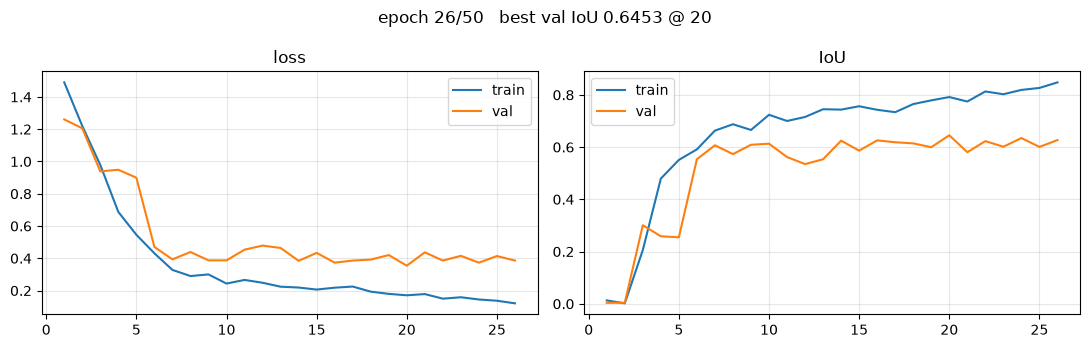

train:   0%|          | 0/12 [00:00<?, ?it/s]

val:   0%|          | 0/3 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [11]:
@torch.no_grad()
def batch_iou(pred: torch.Tensor, target: torch.Tensor, thr: float = THRESHOLD) -> float:
    p = (pred > thr).float()
    t = (target > 0.5).float()
    inter = (p * t).sum()
    union = p.sum() + t.sum() - inter
    return float((inter + 1e-6) / (union + 1e-6))


def run_epoch(loader, *, train: bool) -> tuple[float, float]:
    model.train(train)
    total_loss, total_iou, n_seen = 0.0, 0.0, 0
    bar = tqdm(loader, leave=False, desc="train" if train else "val")
    for x, y in bar:
        x, y = x.to(device), y.to(device)
        with torch.set_grad_enabled(train):
            pred = model(x)
            loss = criterion(pred, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
        bs = x.shape[0]
        total_loss += float(loss.detach()) * bs
        total_iou += batch_iou(pred.detach(), y) * bs
        n_seen += bs
        bar.set_postfix(loss=total_loss / n_seen, iou=total_iou / n_seen)
    return total_loss / max(n_seen, 1), total_iou / max(n_seen, 1)


def plot_history(history, *, epoch, end_epoch, best_iou, best_epoch):
    if not history:
        return
    epochs = [r["epoch"] for r in history]
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    fig.suptitle(f"epoch {epoch}/{end_epoch}   best val IoU {best_iou:.4f} @ {best_epoch}")
    axes[0].plot(epochs, [r["train_loss"] for r in history], label="train")
    axes[0].plot(epochs, [r["val_loss"] for r in history], label="val")
    axes[0].set_title("loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, [r["train_iou"] for r in history], label="train")
    axes[1].plot(epochs, [r["val_iou"] for r in history], label="val")
    axes[1].set_title("IoU"); axes[1].legend(); axes[1].grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


end_epoch = start_epoch + EPOCHS - 1
for epoch in range(start_epoch, end_epoch + 1):
    train_loss, train_iou = run_epoch(train_loader, train=True)
    val_loss, val_iou = run_epoch(val_loader, train=False)
    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_iou": train_iou,
        "val_iou": val_iou,
        "lr_encoder": optimizer.param_groups[0]["lr"],
        "lr_head": optimizer.param_groups[1]["lr"],
    }
    history.append(row)

    is_best = val_iou > best_iou
    if is_best:
        best_iou, best_epoch = val_iou, epoch

    save_kwargs = dict(
        model=model, optimizer=optimizer, scheduler=scheduler,
        epoch=epoch, best_iou=best_iou, best_epoch=best_epoch,
        params=PARAMS, history=history,
    )
    save_checkpoint(LAST_PATH, **save_kwargs)
    if is_best:
        save_checkpoint(BEST_PATH, **save_kwargs)

    clear_output(wait=True)
    print(
        f"epoch {epoch}/{end_epoch}  "
        f"train loss={train_loss:.4f} iou={train_iou:.4f}  "
        f"val loss={val_loss:.4f} iou={val_iou:.4f}  "
        f"best={best_iou:.4f}@{best_epoch}"
        + ("  ★ best" if is_best else "")
    )
    plot_history(history, epoch=epoch, end_epoch=end_epoch, best_iou=best_iou, best_epoch=best_epoch)

print(f"done. best val IoU {best_iou:.4f} @ epoch {best_epoch}")
print(f"best → {BEST_PATH}")
print(f"last → {LAST_PATH}")


## Предсказания

Загружаем `best.pkl` и рисуем для нескольких val-примеров: `tsr_d1`, GT, pred.


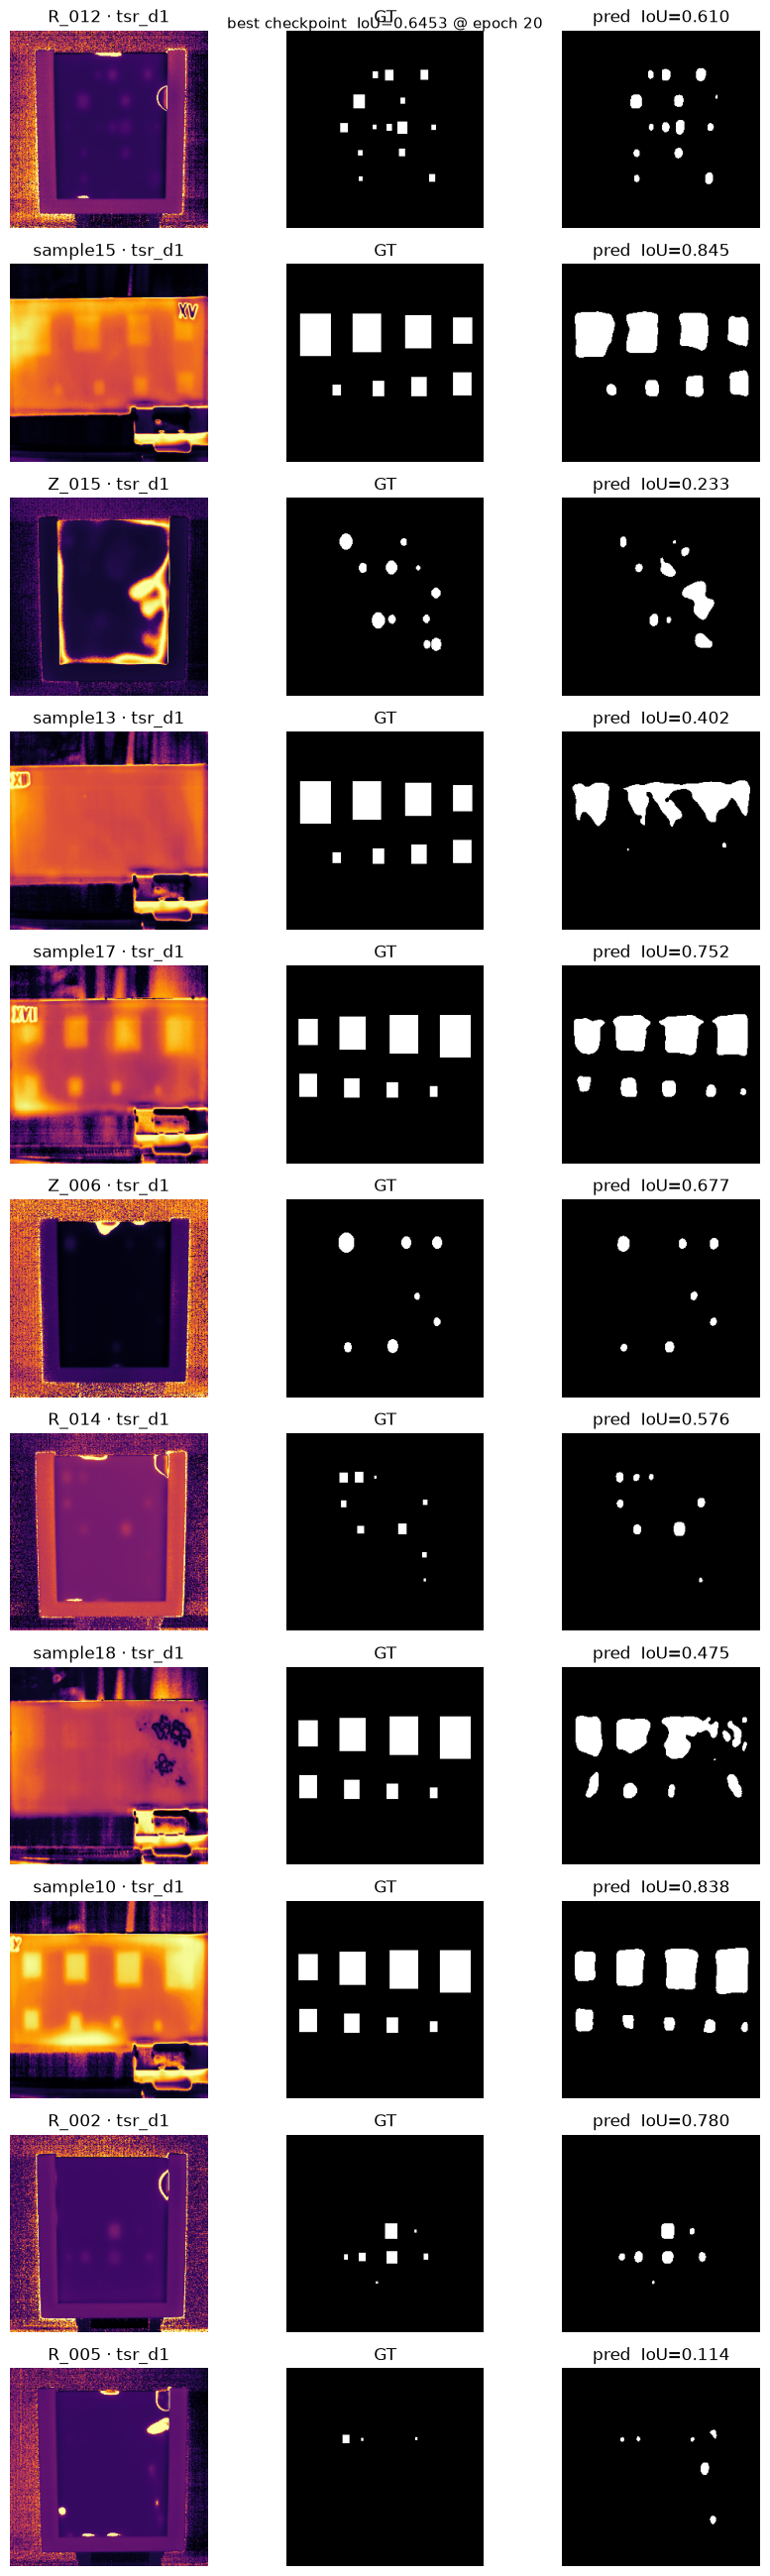

In [14]:
load_model(BEST_PATH, model)
model.eval()

n_show = len(val_ds)
fig, axes = plt.subplots(n_show, 3, figsize=(9, 2.4 * n_show))
if n_show == 1:
    axes = np.expand_dims(axes, 0)

for row, idx in enumerate(val_idx[:n_show]):
    video, mask = full_ds[idx]
    ch = extract_channels(video, PARAMS)[CHANNEL_PERM]
    with torch.no_grad():
        pred = model(ch.unsqueeze(0).to(device)).squeeze().cpu()
    gt = (mask > 0).float()
    if gt.ndim == 3:
        gt = gt.squeeze(0)

    stem = Path(full_ds.items[idx][0]).stem
    axes[row, 0].imshow(ch[0].numpy(), cmap="inferno", vmin=0, vmax=1)
    axes[row, 0].set_title(f"{stem} · tsr_d1")
    axes[row, 1].imshow(gt.numpy(), cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title("GT")
    axes[row, 2].imshow((pred > THRESHOLD).numpy(), cmap="gray", vmin=0, vmax=1)
    axes[row, 2].set_title(f"pred  IoU={iou_score((pred > THRESHOLD).numpy(), gt.numpy()):.3f}")
    for ax in axes[row]:
        ax.axis("off")

fig.suptitle(f"best checkpoint  IoU={best_iou:.4f} @ epoch {best_epoch}", fontsize=11)
fig.tight_layout()
plt.show()
